In [1]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# trying out this output folder type thing. 
OUT = "outputs"; os.makedirs(OUT, exist_ok=True)


def make_key(x):
    if pd.isna(x): return None
    s = re.sub(r"[^A-Z0-9]", "", str(x).upper())
    if s.startswith("NGC"): return s
    if s.isdigit(): return f"NGC{s}"
    return s

def pick_col(df, *cands):
    # case-insensitive column picker
    cols = {c.lower(): c for c in df.columns}
    for name in cands:
        if name.lower() in cols: return cols[name.lower()]
    raise KeyError(f"None of {cands} in {list(df.columns)}")


In [2]:
h1   = pd.read_csv("HarrisPartI.csv")
h3   = pd.read_csv("HarrisPartIII.csv")
vdb  = pd.read_csv("vandenBerg_table2.csv")
kra  = pd.read_csv("Krause21.csv")

# Standardise join keys
h1["key"]  = (h1["Name"] if "Name" in h1.columns else h1["ID"]).apply(make_key)
h3["key"]  = (h3["ID"]   if "ID"   in h3.columns else h3["Name"]).apply(make_key)
vdb["key"] = vdb["#NGC"].apply(lambda x: f"NGC{int(x)}" if pd.notna(x) and str(x).isdigit() else None)

# Krause headings vary: normalise to lowercase for convenience
kra.columns = [c.strip().lower().replace(" ", "_") for c in kra.columns]
kra["key"]  = kra[pick_col(kra, "object", "altname", "name", "cluster", "id", "ngc", "#ngc")].apply(make_key)


print(h1.columns)
print(h3.columns)

Index(['ID', 'Name', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y', 'Z',
       'key'],
      dtype='object')
Index(['ID', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h',
       'mu_V', 'rho_0', 'lg_tc', 'lg_th', 'key'],
      dtype='object')


# Vandenberg AMR

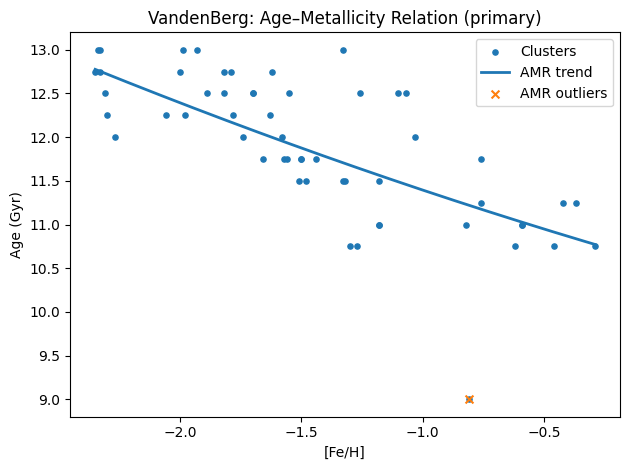

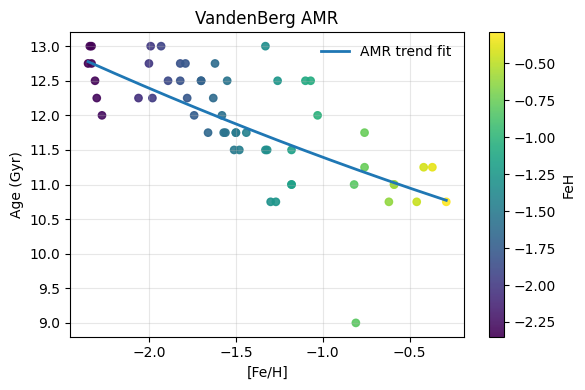

In [ ]:
feh_v = pick_col(vdb, "FeH", "feh", "[Fe/H]")
age_v = pick_col(vdb, "Age", "age")
err_v = next((c for c in vdb.columns if c.lower() in {"age_err","ageerror","age_unc"}), None)

v = vdb.dropna(subset=[feh_v, age_v]).copy()

# Fit a smooth AMR trend
w = None if err_v is None else 1/np.clip(v[err_v].values, 0.1, None)
coef = np.polyfit(v[feh_v], v[age_v], 2, w=w)
p = np.poly1d(coef)

v["Age_trend"] = p(v[feh_v])
v["Age_resid"] = v[age_v] - v["Age_trend"]
AMR_RESID_GYR = 1.8   # tune 1.5–2.5 Gyr if needed
v["amr_outlier"] = v["Age_resid"].abs() > AMR_RESID_GYR

# Plot + save
xs = np.linspace(v[feh_v].min(), v[feh_v].max(), 200)
plt.figure()
plt.scatter(v[feh_v], v[age_v], s=14, label="Clusters")
plt.plot(xs, p(xs), lw=2, label="AMR trend")
oo = v["amr_outlier"]
plt.scatter(v.loc[oo, feh_v], v.loc[oo, age_v], s=32, marker="x", label="AMR outliers")
plt.xlabel("[Fe/H]"); plt.ylabel("Age (Gyr)")
plt.title("VandenBerg: Age–Metallicity Relation (primary)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/amr_vdb_primary.png", dpi=150); plt.show()

amr_candidates = v.loc[oo, ["key","Name",feh_v,age_v,"Age_resid"]].rename(
    columns={feh_v:"FeH", age_v:"Age"}
)
amr_candidates.to_csv(f"{OUT}/amr_candidates_vdb.csv", index=False)

# Choose a sensible colour dimension from what's actually in `v`
_color_priority = ["R_gc", "R_Sun", "Z", "mu_V", "c", "r_h", "lg_tc", "lg_th", "FeH", "Age"]
COLOR_COL = next((c for c in _color_priority if c in v.columns), age_v)
color_label = COLOR_COL + (" (kpc)" if COLOR_COL in ["R_gc","R_Sun"] else "")

fig, ax = plt.subplots(figsize=(6,4))

# scatter points with colorbar
sc = ax.scatter(v[feh_v], v[age_v], c=v[COLOR_COL], s=28, alpha=0.9)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(color_label)

# overlay your smooth AMR fit 
xgrid = np.linspace(v[feh_v].min(), v[feh_v].max(), 200)
ax.plot(xgrid, p(xgrid), lw=2, label="AMR trend fit")

ax.set_title("VandenBerg AMR")
ax.set_xlabel("[Fe/H]")
ax.set_ylabel("Age (Gyr)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/Vandenberg_AMR_colorbar.png", dpi=300, bbox_inches="tight")
plt.show()




# Vberg + Krause Comparison

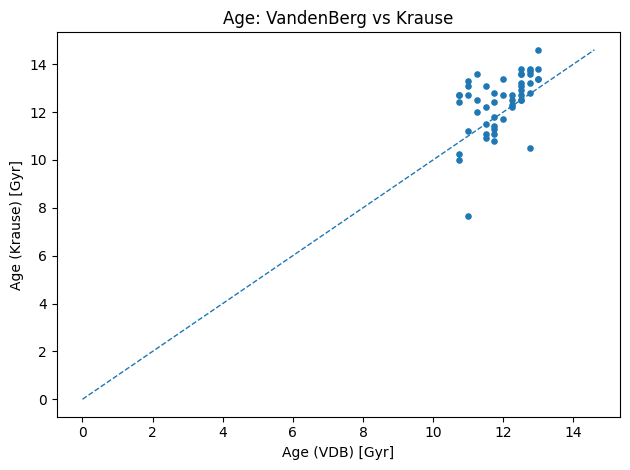

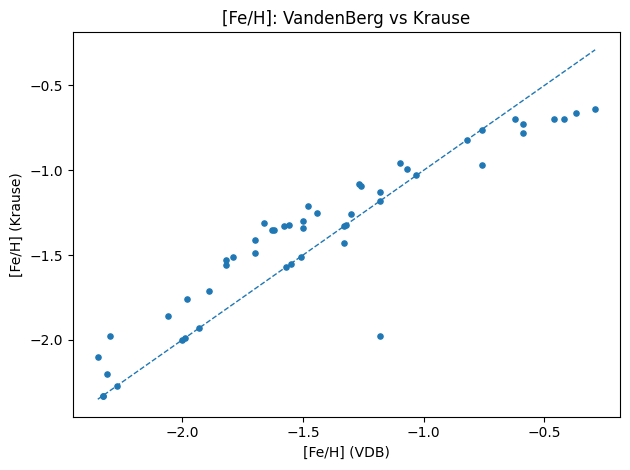

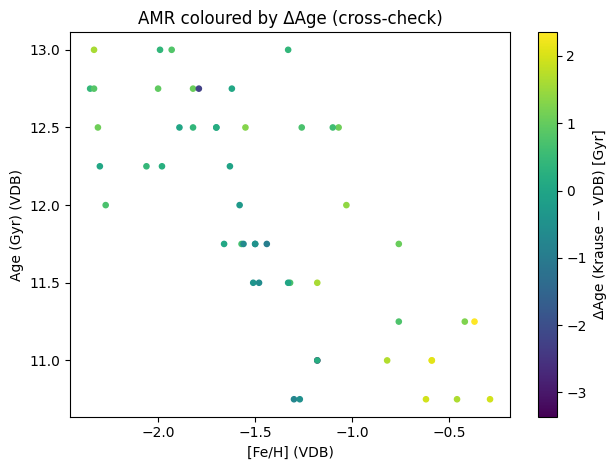

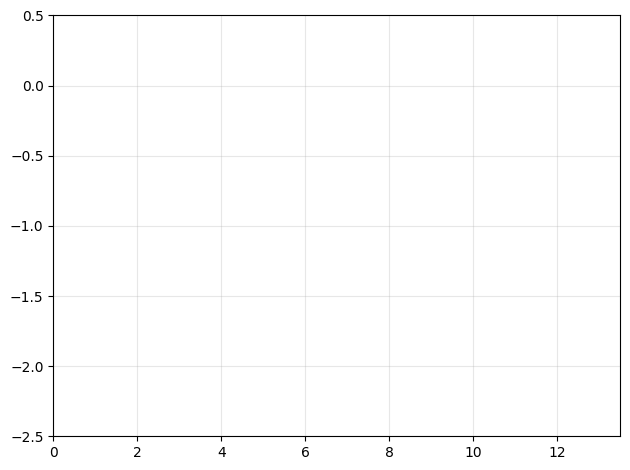

In [ ]:
# Build combined table of matched clusters with both sources
vk = pd.merge(
    vdb[["key","Name", feh_v, age_v]].rename(columns={feh_v:"FeH_vdb", age_v:"Age_vdb"}),
    kra.rename(columns={pick_col(kra,"feh","FeH"):"FeH_k", pick_col(kra,"age","Age"):"Age_k"})[["key","FeH_k","Age_k"] + ([ "class"] if "class" in kra.columns else [])],
    on="key", how="inner"
)

# Consistency plots
plt.figure(); plt.scatter(vk["Age_vdb"], vk["Age_k"], s=14)
mx = float(np.nanmax([vk["Age_vdb"].max(), vk["Age_k"].max()]))
plt.plot([0,mx],[0,mx],"--",lw=1); plt.xlabel("Age (VDB) [Gyr]"); plt.ylabel("Age (Krause) [Gyr]")
plt.title("Age: VandenBerg vs Krause"); plt.tight_layout()
plt.savefig(f"{OUT}/age_vdb_vs_krause.png", dpi=150); plt.show()

plt.figure(); plt.scatter(vk["FeH_vdb"], vk["FeH_k"], s=14)
mn = float(np.nanmin([vk["FeH_vdb"].min(), vk["FeH_k"].min()])); mx = float(np.nanmax([vk["FeH_vdb"].max(), vk["FeH_k"].max()]))
plt.plot([mn,mx],[mn,mx],"--",lw=1); plt.xlabel("[Fe/H] (VDB)"); plt.ylabel("[Fe/H] (Krause)")
plt.title("[Fe/H]: VandenBerg vs Krause"); plt.tight_layout()
plt.savefig(f"{OUT}/feh_vdb_vs_krause.png", dpi=150); plt.show()

# AMR coloured by ΔAge (Krause−VDB) — useful diagnostic idk
vk["dAge"] = vk["Age_k"] - vk["Age_vdb"]
plt.figure(); sc=plt.scatter(vk["FeH_vdb"], vk["Age_vdb"], s=14, c=vk["dAge"])
plt.colorbar(sc, label="ΔAge (Krause − VDB) [Gyr]")
plt.xlabel("[Fe/H] (VDB)"); plt.ylabel("Age (Gyr) (VDB)")
plt.title("AMR coloured by ΔAge (cross-check)")
plt.tight_layout(); plt.savefig(f"{OUT}/amr_vdb_coloured_by_dAge.png", dpi=150); plt.show()

vk.to_csv(f"{OUT}/krause_vdb_combined.csv", index=False)

plt.legend(['Krause', 'VandenBerg'], frameon=False)
plt.grid(alpha=0.3)

# Conservative, readable ranges (only applied if axes are [Age] in Gyr and [Fe/H])
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
if xmax - xmin < 20:
    ax.set_xlim(0, 13.5)
if ymax - ymin < 5:
    ax.set_ylim(-2.5, 0.5)

plt.tight_layout()
plt.savefig(f"{OUT}/Vberg_Krause_comparison.png", dpi=300, bbox_inches="tight")


# Harris pI and pIII (Dynamics)

In [5]:
def ffix_key(x):
    if pd.isna(x): 
        return None
    s = str(x).strip().upper()
    s = s.replace(" ", "").replace("_", "")
    # remove or add NGC as needed
    if s.startswith("NGC"):
        s = s.replace("NGC", "")
    # ensure consistent format like "NGC104"
    if s.isdigit():
        return f"NGC{int(s)}"
    return f"NGC{s}"

# Rebuild keys consistently
h1["key"] = h1["ID"].apply(ffix_key)
h3["key"] = h3["ID"].apply(ffix_key)


print("len(harris1):", len(h1))
print("len(harris3):", len(h3))
print("non-null keys:")
print("  Harris I:", h1["key"].notna().sum())
print("  Harris III:", h3["key"].notna().sum())
print("common keys:", len(set(h1["key"]) & set(h3["key"])))


j = h1[["key","L"]].merge(h3[["key","v_r"]], on="key", how="inner")
j.dropna(subset=["L","v_r"], inplace=True)
print("Rotation sample:", j.shape)
print(j.head())

# --- fit v ≈ A*sin(L - φ) ---
Lrad = np.deg2rad(j[L_col].values)
y = j[vr_col].values
X = np.vstack([np.sin(Lrad), np.cos(Lrad)]).T
(a, b), *_ = np.linalg.lstsq(X, y, rcond=None)
A = np.hypot(a, b)
phi = np.degrees(np.arctan2(-b, a))

j["v_fit"] = A * np.sin(np.deg2rad(j[L_col] - phi))
j["v_resid"] = y - j["v_fit"]

# --- plots ---
plt.figure()
plt.scatter(j[L_col], y, s=10, label="data")
Lgrid = np.linspace(0, 360, 361)
plt.plot(Lgrid, A*np.sin(np.deg2rad(Lgrid - phi)), label="fit")
plt.xlabel("Galactic longitude l (deg)")
plt.ylabel(f"{vr_col} (km/s)")
plt.title("Rotation proxy: v vs l (Harris I+III)")
plt.legend(); plt.show()

plt.figure()
plt.hist(j["v_resid"], bins=25)
plt.xlabel(f"{vr_col} residual (km/s)")
plt.title("Residuals to rotation fit"); plt.show()

# flag rotation outliers
ROT_RESID = 70.0
j["rot_outlier"] = j["v_resid"].abs() > ROT_RESID

ROT_RESID = 70  # km/s, typical threshold
j["rot_outlier"] = j["v_resid"].abs() > ROT_RESID
print(j[j["rot_outlier"]].head(10))



len(harris1): 157
len(harris3): 157
non-null keys:
  Harris I: 157
  Harris III: 157
common keys: 157
Rotation sample: (143, 3)
           key       L    v_r
0       NGC104  305.89  -18.0
1       NGC288  152.30  -45.4
2       NGC362  301.53  223.5
3  NGCWHITING1  161.22 -130.6
4      NGC1261  270.54   68.2


NameError: name 'L_col' is not defined

Merged rows with L & a velocity: 143
Using MAD threshold: ±126.2 km/s
Sinusoidal fit: v0=-5.4, A=-122.8, L0=2.6


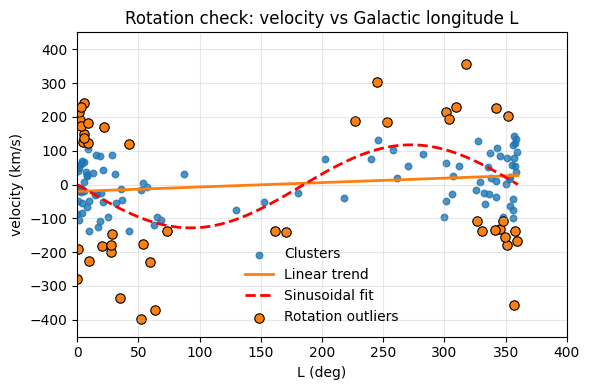

,Name,L,vel,v_fit,v_resid
58,NaN,0.13,-279.1,-20.341775,-258.758225
104,NaN,0.20,-189.4,-20.332632,-169.067368
97,NaN,1.14,214.9,-20.209857,235.109857
83,NaN,2.10,190.2,-20.084469,210.284469
117,M 70,2.85,227.8,-19.986509,247.786509
126,NaN,3.39,172.5,-19.915979,192.415979
65,NaN,4.90,126.3,-19.718754,146.018754
64,M 9,5.54,239.8,-19.635162,259.435162
119,M 54,5.61,149.2,-19.626019,168.826019
130,NaN,5.76,136.2,-19.606427,155.806427


slope = 0.131 km/s per deg, intercept = -20.4
Pearson r = 0.14, p = 8.981e-02


In [ ]:
# === Rotation analysis: merge Harris I (L) with Harris III (velocities) ===


# 1) Merge on ID
df_rot = (
    h1[["ID", "Name", "L", "B", "R_Sun", "R_gc"]]
    .merge(h3[["ID", "v_r", "v_LSR"]], on="ID", how="inner")
    .copy()
)

# 2) Build a single velocity column: prefer v_LSR if present, else v_r
df_rot["vel"] = df_rot["v_LSR"].where(df_rot["v_LSR"].notna(), df_rot["v_r"])
df_rot = df_rot.dropna(subset=["L", "vel"]).reset_index(drop=True)

print(f"Merged rows with L & a velocity: {len(df_rot)}")
if len(df_rot) == 0:
    raise ValueError("After merging, no rows have both L and (v_LSR or v_r). Check your columns/NaNs.")

# 3) Fit a simple linear rotation model: vel ≈ a + b * L
coef = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
fit = np.poly1d(coef)
df_rot["v_fit"] = fit(df_rot["L"].values)
df_rot["v_resid"] = df_rot["vel"].values - df_rot["v_fit"].values

# 4) Robust outlier threshold using MAD
resid = df_rot["v_resid"]
mad = (resid - resid.median()).abs().median()
thr = 1.5 * mad if mad > 0 else resid.abs().quantile(0.9)
df_rot["rot_outlier"] = df_rot["v_resid"].abs() > thr
print(f"Using {'MAD' if mad>0 else 'P90'} threshold: ±{thr:.1f} km/s")



# 5) Plot: linear + sinusoidal rotation fits together
from scipy.optimize import curve_fit

# Fit the sinusoidal model
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

# Use linear fit slope/intercept as part of initial guess
p0 = [coef[1], np.std(df_rot["vel"]), 0]  # v0 ≈ intercept, amplitude ≈ std(vel)
popt, _ = curve_fit(v_sin, df_rot["L"], df_rot["vel"], p0=p0, maxfev=10000)
df_rot["v_sin"] = v_sin(df_rot["L"], *popt)
print(f"Sinusoidal fit: v0={popt[0]:.1f}, A={popt[1]:.1f}, L0={popt[2]:.1f}")

# Plot both fits on the same graph
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df_rot["L"], df_rot["vel"], s=22, alpha=0.8, label="Clusters")

Lgrid = np.linspace(0, 360, 360)
ax.plot(Lgrid, fit(Lgrid), "C1-", lw=2, label="Linear trend")
ax.plot(Lgrid, v_sin(Lgrid, *popt), "r--", lw=2, label="Sinusoidal fit")

# Highlight rotation outliers
oo = df_rot["rot_outlier"]
ax.scatter(df_rot.loc[oo, "L"], df_rot.loc[oo, "vel"],
           s=46, edgecolor="k", linewidth=0.8, label="Rotation outliers")

ax.set_xlim(0, 400)
ax.set_ylim(-450, 450)
ax.set_xlabel("L (deg)")
ax.set_ylabel("velocity (km/s)")
ax.set_title("Rotation check: velocity vs Galactic longitude L")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/Rotation_combined_linear_sinusoidal.png", dpi=300, bbox_inches="tight")
plt.show()


# 6) Compact table of rotation outliers
name_col = next((c for c in ["Name","ID","key","Cluster","name","cluster"] if c in df_rot.columns), None)
cols = [c for c in [name_col, "L", "vel", "v_fit", "v_resid"] if c is not None]
display(df_rot.loc[oo, cols].sort_values("L"))

r, p = stats.pearsonr(df_rot["L"], df_rot["vel"])
print(f"slope = {coef[0]:.3f} km/s per deg, intercept = {coef[1]:.1f}")
print(f"Pearson r = {r:.2f}, p = {p:.3e}")

from scipy.optimize import curve_fit
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))





In [ ]:
### === Accreted fractions & exports ===

# Ensure OUT exists (if not already created above)
try:
    OUT
except NameError:
    OUT = "output"
os.makedirs(OUT, exist_ok=True)

# 1) Rotation-accreted fraction (outliers by MAD/P90 threshold from previous cell)
total = len(df_rot)
n_out = int(df_rot["rot_outlier"].sum())
pct = 100.0 * n_out / total if total else 0.0
print(f"[Rotation] Outliers: {n_out} / {total}  ->  {pct:.1f}%")

# Save summary + outlier list
summary = pd.DataFrame(
    {"metric": ["rotation_total", "rotation_outliers", "rotation_outlier_pct"],
     "value":   [total, n_out, pct]}
)
summary.to_csv(f"{OUT}/rotation_accreted_summary.csv", index=False)

cols_basic = ["ID","Name","L","vel"]
cols_extra = ["v_fit","v_resid"]
cols_present = [c for c in cols_basic + cols_extra if c in df_rot.columns]
df_rot.loc[df_rot["rot_outlier"], cols_present].to_csv(f"{OUT}/rotation_outliers.csv", index=False)

# 2) Sensitivity sweep vs threshold multiplier (see how % changes)
# Reuse residuals from your previous cell; compute if missing
if "v_resid" not in df_rot.columns:
    # fall back to linear fit residuals if needed
    coef_tmp = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
    fit_tmp = np.poly1d(coef_tmp)
    df_rot["v_resid"] = df_rot["vel"].values - fit_tmp(df_rot["L"].values)

resid = df_rot["v_resid"].to_numpy()
mad = np.median(np.abs(resid - np.median(resid)))
base_thr = mad if mad > 0 else np.quantile(np.abs(resid), 0.9)

rows = []
for mult in [1.0, 1.25, 1.5, 2.0]:
    thr_m = mult * base_thr
    mask = np.abs(resid) > thr_m
    rows.append({
        "multiplier": mult,
        "threshold_kms": float(thr_m),
        "n_outliers": int(mask.sum()),
        "pct": 100.0 * mask.mean()
    })
sens = pd.DataFrame(rows)
sens.to_csv(f"{OUT}/rotation_outlier_sensitivity.csv", index=False)
display(sens.round(2))

# 3) Combined accreted fraction (Rotation OR AMR), if an AMR flag exists
# Accept either:
#   - amr2 with columns ["ID", "AMR_outlier"], or
#   - v   with columns ["ID" or "Name", "AMR_outlier"]
def _find_amr_table():
    if "amr2" in globals() and isinstance(globals()["amr2"], pd.DataFrame):
        return "amr2", globals()["amr2"]
    if "v" in globals() and isinstance(globals()["v"], pd.DataFrame) and "AMR_outlier" in globals()["v"].columns:
        return "v", globals()["v"]
    return None, None

amr_name, amr_df = _find_amr_table()
if amr_df is not None and "AMR_outlier" in amr_df.columns:
    # choose a join key we actually share
    join_key = "ID" if "ID" in amr_df.columns and "ID" in df_rot.columns else None
    if join_key is None:
        # try Name if ID not available
        join_key = "Name" if "Name" in amr_df.columns and "Name" in df_rot.columns else None

    if join_key is not None:
        comb = df_rot[[join_key, "rot_outlier"]].merge(
            amr_df[[join_key, "AMR_outlier"]],
            on=join_key,
            how="left"
        )
        comb["AMR_outlier"] = comb["AMR_outlier"].fillna(False)
        comb["any_outlier"] = comb["rot_outlier"] | comb["AMR_outlier"]

        tot = len(comb)
        n_any = int(comb["any_outlier"].sum())
        pct_any = 100.0 * n_any / tot if tot else 0.0

        print(f"[Combined] Accreted candidates (Rotation ∪ AMR): {n_any} / {tot}  ->  {pct_any:.1f}%")
        comb.to_csv(f"{OUT}/accreted_flags_combined.csv", index=False)
    else:
        print("[Combined] Skipped: no common join key (ID or Name) between rotation frame and AMR table.")
else:
    print("[Combined] Skipped: no AMR_outlier table found (add AMR flagging first).")


[Rotation] Outliers: 47 / 143  ->  32.9%


,multiplier,threshold_kms,n_outliers,pct
0,1.00,84.16,71,49.65
1,1.25,105.20,60,41.96
2,1.50,126.24,47,32.87
3,2.00,168.32,30,20.98


[Combined] Skipped: no AMR_outlier table found (add AMR flagging first).


In [ ]:
# === Sinusoidal residuals & alternate outlier flag (non-destructive) ===


try:
    v_sin, popt
except NameError as e:
    raise RuntimeError("Run the sinusoidal fit cell first to define v_sin and popt=[v0, A, L0].") from e

# Compute sinusoidal residuals
df_rot["v_fit_sin"] = v_sin(df_rot["L"], *popt)
df_rot["v_resid_sin"] = df_rot["vel"] - df_rot["v_fit_sin"]

# Robust threshold on SIN residuals (keeps your existing rot_outlier untouched)
res = df_rot["v_resid_sin"]
mad = (res - res.median()).abs().median()
thr_sin = 1.5 * mad if mad > 0 else res.abs().quantile(0.9)
df_rot["rot_outlier_sin"] = res.abs() > thr_sin

print(f"[SIN residuals] MAD={mad:.1f} → threshold ±{thr_sin:.1f} km/s")
print(f"Outliers by SIN residuals: {int(df_rot['rot_outlier_sin'].sum())} / {len(df_rot)}")

# Save a separate outlier list for SIN residuals
cols = [c for c in ["ID","Name","L","R_gc","vel","v_fit_sin","v_resid_sin"] if c in df_rot.columns]
df_rot.loc[df_rot["rot_outlier_sin"], cols].to_csv(f"{OUT}/rotation_outliers_sin.csv", index=False)


[SIN residuals] MAD=84.1 → threshold ±126.1 km/s
Outliers by SIN residuals: 42 / 143


In [9]:
# === Prograde vs retrograde fraction (relative to fitted phase) ===
# A cluster is "prograde" if (vel - v0) and sin(L - L0) have the same sign.
v0, A, L0 = popt
phase = np.sin(np.radians(df_rot["L"] - L0))
sign_prod = (df_rot["vel"] - v0) * phase
df_rot["prograde"] = sign_prod > 0

tot = len(df_rot)
pct_pro = 100.0 * df_rot["prograde"].mean() if tot else 0.0
pct_retro = 100.0 - pct_pro
print(f"Prograde: {pct_pro:.1f}%   Retrograde: {pct_retro:.1f}%")

# Save small summary
import pandas as pd
pd.DataFrame({"metric":["prograde_pct","retrograde_pct"], "value":[pct_pro, pct_retro]}) \
  .to_csv(f"{OUT}/prograde_retrograde_share.csv", index=False)


Prograde: 40.6%   Retrograde: 59.4%


In [10]:
# === Rotation amplitude & residual dispersion vs R_gc bins ===
from scipy.optimize import curve_fit

bins = [0, 5, 10, 20, 50]  # kpc; tweak as you like
df_rot["Rbin"] = pd.cut(df_rot["R_gc"], bins=bins, right=False)

def fit_amp(sub):
    if len(sub) < 8:
        return np.nan, np.nan, np.nan
    p, cov = curve_fit(v_sin, sub["L"], sub["vel"], p0=popt, maxfev=20000)
    v0b, Ab, L0b = p
    # residuals vs that bin's sinusoid
    resid_b = sub["vel"] - v_sin(sub["L"], *p)
    return v0b, Ab, float(resid_b.std())

rows = []
for rb, sub in df_rot.groupby("Rbin", observed=True):
    v0b, Ab, sigb = fit_amp(sub)
    rows.append({"R_bin": str(rb), "N": len(sub), "A_kms": Ab, "sigma_resid_kms": sigb})

rot_radial = pd.DataFrame(rows)
display(rot_radial.round(2))
rot_radial.to_csv(f"{OUT}/rotation_radial_stats.csv", index=False)


,R_bin,N,A_kms,sigma_resid_kms
0,"[0, 5)",68,441.34,115.80
1,"[5, 10)",29,-238.84,114.60
2,"[10, 20)",27,-131.92,145.18
3,"[20, 50)",13,-109.73,127.43


## extra


In [ ]:
print("len(harris1):", len(h1))
print("len(harris3):", len(h3))
print("non-null keys:")
print("  Harris I:", h1["key"].notna().sum())
print("  Harris III:", h3["key"].notna().sum())
print("common keys:", len(set(h1["key"]) & set(h3["key"])))


len(harris1): 157
len(harris3): 157
non-null keys:
  Harris I: 157
  Harris III: 157
common keys: 157


In [ ]:
# === Candidate accreted clusters: combine flags where available ===
import pandas as pd

# Gather flags from objects if they exist in this notebook
cand_map = {}

def add_flags(df_obj, key_flag, flag_col):
    if df_obj is None or flag_col not in df_obj.columns:
        return
    name_col = next((c for c in ["Name","key","ID","Cluster","name","cluster"] if c in df_obj.columns), None)
    for idx, row in df_obj.loc[df_obj[flag_col]].iterrows():
        ident = row[name_col] if name_col else idx
        d = cand_map.setdefault(ident, {"AMR_outlier": False, "ROT_outlier": False})
        d[key_flag] = True


# Example: suppose you set amr2["AMR_outlier"] in your AMR section:
if "amr2" in globals():
    add_flags(amr2, "AMR_outlier", "AMR_outlier")

# Rotation outliers from the dynamics section:
if "rot" in globals():
    add_flags(rot, "ROT_outlier", "ROT_outlier")

candidates = pd.DataFrame.from_dict(cand_map, orient="index")
if not candidates.empty:
    candidates["LikelyAccreted"] = candidates["AMR_outlier"] | candidates["ROT_outlier"]
    candidates.index.name = "Cluster"
    display(candidates.sort_values(["LikelyAccreted","AMR_outlier","ROT_outlier"], ascending=False))
    candidates.to_csv("candidate_accreted_clusters.csv")
    print("Saved: candidate_accreted_clusters.csv")
else:
    print("No flags found yet. (Run the AMR outlier/rotation cells first.)")


No flags found yet. (Run the AMR outlier/rotation cells first.)
